<a href="https://colab.research.google.com/github/skwotjd/2026_tues_bigdatacomputing_class/blob/main/class_pandas0331_5_week.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ✅ 데이터 과학 파이프라인의 전 과정
- Numpy : 다차원 배열 생성, 결합(concatenate(), vstack(),hstack(), column_stack()), 셔플링, 필터링(인덱싱/슬라이싱)

- Pandas : 데이터 구조화, 타입 변환, 그룹 분석(groupby(), pivot_table(), concat(), merge()), 데이터 추출(인덱싱, 슬라이싱), 결측치 보간(fillna(), isna(), dropna())

- 시각화 : matplotlib, seaborn, Pandas의 시각화 기능, DataFrame의 시각화 기능

- 데이터 분석 흐름: 데이터 생성(Numpy) → 데이터 구조화(Pandas) → 정제(Pre-processing) → 탐색적 데이터 분석(EDA) : 시각화 순서로 진행

- NumPy 기반의 시뮬레이션 코드를 Pandas의 DataFrame 구조로 확장하면, 데이터에 이름을 붙이고(Indexing), 통계치를 한눈에 확인하며, 시각화 라이브러리와의 연동




## ✅ Pandas 기능
- Series

In [ ]:
#------------------------
#Series : List
#------------------------
import pandas as pd
import numpy as np

#인덱스 자동 생성, 컬럼 이름 0
s = pd.Series([1,2,3,np.nan,5,6]) #Series 대문자 맞추기
s = pd.Series(np.random.randn(5)) #넘파이를 이용한 난수 5개
print(s)

#인덱스 지정
s = pd.Series(np.random.randn(5), index =[1,2,3,4,5]) #인덱스로 앞에 번호 지정
print("\n",s)

#시리즈의 이름 지정 name="score"
s = pd.Series(np.random.randint(60,90,5), name ="score") #60~90 사이에 있는 무작위 5개의 데이터
print("\n",s)

#시리즈의 데이터 타입 확인 type(s)
print("\n",type(s))

#시리즈의 결측치 확인 isna()
s= pd.Series([1,2,3,np.nan,5,6])
print(s.isna())

#시리즈 값 추출
print("\n",s[0]) #인덱싱
print(s[:3]) #0~2까지의 데이터만 슬라이싱

#시리즈의 인덱스 변경
s=pd.Series([1,2,3,np.nan,5,6],index=[1,2,3,4,5,6])
print("\n",s)

#(2)
s =pd.Series([1,2,3,np.nan,5,6])
s.index = [1,2,3,4,5,6]
print("\n",s)

#시리즈 값 수정
s = pd.Series([1,2,3,np.nan,5,6])
s[0] = 0 #결측치 처리 - 0으로 지정
print("\n",s)

#시리즈의 새로운 값 추가
s = pd.Series([1,2,3,np.nan,5,6])
s[7]=7  #s[인덱스 값] = 추가할 값
print("\n",s)


0    0.135337
1   -0.537836
2   -0.243879
3   -1.710110
4    1.053966
dtype: float64

 1   -0.558522
2   -2.097133
3    0.223840
4   -0.218055
5   -0.001227
dtype: float64

 0    60
1    80
2    76
3    86
4    88
Name: score, dtype: int64

 <class 'pandas.core.series.Series'>
0    False
1    False
2    False
3     True
4    False
5    False
dtype: bool

 1.0
0    1.0
1    2.0
2    3.0
dtype: float64

 1    1.0
2    2.0
3    3.0
4    NaN
5    5.0
6    6.0
dtype: float64

 1    1.0
2    2.0
3    3.0
4    NaN
5    5.0
6    6.0
dtype: float64

 0    0.0
1    2.0
2    3.0
3    NaN
4    5.0
5    6.0
dtype: float64

 0    1.0
1    2.0
2    3.0
3    NaN
4    5.0
5    6.0
7    7.0
dtype: float64


In [ ]:
#---------------------------------
#Series : dictionary
#---------------------------------
import pandas as pd
import numpy as np

income = {'jan ': 80000,'feb':90000,'mar':79000}
income_s = pd.Series(income,name="salary")
print(income_s)
print("\n",income_s.index.to_list()) #인덱스 리스트 출력
print("\n",income_s.values) #값 출력
income_s.index=['1M','2M','3M'] #인덱스 수정
print("\n",income_s)

#시리즈에서 최대값 찾기
#(1)
print("\n",income_s.max()) #.max() 90000이 최대값
#(2)
max_index=np.argmax(income_s)
print("\n",max_index) #가장 큰 값의 인덱스 출력
print("\n",income_s[max_index])


jan     80000
feb     90000
mar     79000
Name: salary, dtype: int64

 ['jan ', 'feb', 'mar']

 [80000 90000 79000]

 1M    80000
2M    90000
3M    79000
Name: salary, dtype: int64

 90000

 1

 90000


/tmp/ipykernel_8198/1248978302.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("\n",income_s[max_index])


## ✅ Pandas 기능
  - DataFrame
  - 병합

In [ ]:
#---------------------------------------------
#Dataframe : 복수 개의 시리즈를 딕셔너리로 이용
#---------------------------------------------
import pandas as pd
import numpy as np

month_s=pd.Series(['jan','feb','mar'])
imcome_s=pd.Series([9700,6000,9000]) #데이터 갯수를 맞춰주기 3=3
expense_s=pd.Series([5040,7000,8900])

df=pd.DataFrame({'월':month_s,'수입':imcome_s,'지출':expense_s}, index=range(0,3))
print(df)

#데이터프레임 속성
print("\n",df.index.to_list()) #인덱스만 추출
print("\n",df.columns.to_list()) #상단 리스트만 추출
print("\n",df.values) #numpy 2d-array #값 추출

#데이터프레임의 인덱스 재설정
df.index=["M1","M2","M3"]
print("\n",df)

#데이터프레임의 컬럼(열) 추출
#(1) 인덱싱
print("\n",df['월']) #시리즈 반환
print("\n",df[['월','지출']]) #일부 데이터프레임 반환

# 데이터프레임의 특정 행 추출
# print("\n",df['M1']) #error

print("\n",df.loc['M1']) #첫번째 행 추출
print("\n",df.loc[["M1","M3"]])

#데이터프레임의 특정 데이터 추출 (행,열)
print("\n", df.loc['M1','수입']) #.🔔 코드 주고 어떤 데이터를 출력한건지 알아야 함.🔔

#데이터프레임에 새로운 컬럼 추가
df['잔액']=df['수입']-df['지출'] #넘파이의 벡터화 연산
print("\n",df)
print("\n",df.head(2)) #위에서부터 2개만 추출
print("\n",df.tail(2))

#논리 인덱싱 조건을 이용해서 새로운 컬럼 추가
df['적자'] = np.where(df['잔액']<0,"-","+")
print("\n",df)

#논리 인덱싱을 이용하여 특정 조건을 만족하는 데이터 프레임 필터링
print("\n",df[df['잔액']>0])


     월    수입    지출
0  jan  9700  5040
1  feb  6000  7000
2  mar  9000  8900

 [0, 1, 2]

 ['월', '수입', '지출']

 [['jan' 9700 5040]
 ['feb' 6000 7000]
 ['mar' 9000 8900]]

       월    수입    지출
M1  jan  9700  5040
M2  feb  6000  7000
M3  mar  9000  8900

 M1    jan
M2    feb
M3    mar
Name: 월, dtype: object

       월    지출
M1  jan  5040
M2  feb  7000
M3  mar  8900

 월      jan
수입    9700
지출    5040
Name: M1, dtype: object

       월    수입    지출
M1  jan  9700  5040
M3  mar  9000  8900

 9700

       월    수입    지출    잔액
M1  jan  9700  5040  4660
M2  feb  6000  7000 -1000
M3  mar  9000  8900   100

       월    수입    지출    잔액
M1  jan  9700  5040  4660
M2  feb  6000  7000 -1000

       월    수입    지출    잔액
M2  feb  6000  7000 -1000
M3  mar  9000  8900   100

       월    수입    지출    잔액 적자
M1  jan  9700  5040  4660  +
M2  feb  6000  7000 -1000  -
M3  mar  9000  8900   100  +

       월    수입    지출    잔액 적자
M1  jan  9700  5040  4660  +
M3  mar  9000  8900   100  +


In [ ]:
#--------------------------------
#DataFrame 합치기 : pd.concat()
#--------------------------------
import pandas as pd
import numpy as np

df1 =pd.DataFrame({'A':['A0','A1'],'B':['B0','B1']})
df2 =pd.DataFrame({'A':['A2','A3'],'B':['B2','B3']})
df3 =pd.DataFrame({'C':['A2','A3']}) #NaN
df4 =pd.DataFrame({'D':['A2']})

print(df1)
print("\n",df1.shape)
print("\n",df2)
print("\n",df3)
print("\n",df4)

#위-아래로 합치기
result_v = pd.concat([df1,df2],axis=0, join='outer') #outer -> 행에 대한 합집합
print("\n",result_v)

result_v = pd.concat([df1,df2,df3],axis=0, join='outer')
print("\n",result_v)


    A   B
0  A0  B0
1  A1  B1

 (2, 2)

     A   B
0  A2  B2
1  A3  B3

     C
0  A2
1  A3

     D
0  A2

     A   B
0  A0  B0
1  A1  B1
0  A2  B2
1  A3  B3

      A    B    C
0   A0   B0  NaN
1   A1   B1  NaN
0   A2   B2  NaN
1   A3   B3  NaN
0  NaN  NaN   A2
1  NaN  NaN   A3


## ✅ Pandas 기능
 - pd.concat()

In [ ]:
import pandas as pd

#-------------------------------------------------
#두 개의 1월과 2월의 매출 표 생성
#-------------------------------------------------
jan= pd.DataFrame({'매출':[100,200]},index= ['A상품','B상품'])
print("\n",jan)

feb=pd.DataFrame({'매출':[150,300], '할인율':[0.1,0.2]}, index= ['A상품','C상품'])
print("\n",feb)
print("-"*100)

#------------------------------------------------
# 1. 1월과 2월을 통합하기
#------------------------------------------------
total_outer = pd.concat([jan,feb], axis= 0, join='outer') #outer= 합집합 #없는 자료는 NaN
print("\n",total_outer)

#------------------------------------------------
# 2. 월별 매출 정보만 통합하기
#------------------------------------------------

total_inner = pd.concat([jan,feb], axis= 0, join='inner') #inner= 교집합
print("\n",total_inner)
print("-"*100)

#------------------------------------------------
# 3. 1월과 2월 상품에 대한 내용 통합하기 : axis = 1 (모든 컬럼이 다 나옴)
#------------------------------------------------
total_outer = pd.concat([jan,feb], axis= 1, join='outer', keys=['jan','feb']) #outer= 합집합 #없는 자료는 NaN #가로로 붙이기
print("\n",total_outer)

#------------------------------------------------
# 4. 월별 매출 정보만 통합하기
#------------------------------------------------
total_inner = pd.concat([jan,feb], axis= 1, join='inner', keys=['jan','feb']) #inner= 교집합 #없는 자료는 NaN #가로로 붙이기
print("\n", total_inner)








       매출
A상품  100
B상품  200

       매출  할인율
A상품  150  0.1
C상품  300  0.2
----------------------------------------------------------------------------------------------------

       매출  할인율
A상품  100  NaN
B상품  200  NaN
A상품  150  0.1
C상품  300  0.2

       매출
A상품  100
B상품  200
A상품  150
C상품  300
----------------------------------------------------------------------------------------------------

        jan    feb     
        매출     매출  할인율
A상품  100.0  150.0  0.1
B상품  200.0    NaN  NaN
C상품    NaN  300.0  0.2

      jan  feb     
      매출   매출  할인율
A상품  100  150  0.1


#### 응용문제 : 데이터 통합 및 결측치 제어 및 seaborn 시각화





✅ 환경 설정 및 한글 폰트 로드 완료
----------------------------------------------------------------------------------------------------
    기온
5월  20
6월  22
7월  25
      기온   풍속
5월  21.0  3.2
6월   NaN  4.1
8월  26.0  3.8
----------------------------------------------------------------------------------------------------
            기온   풍속
2021년 5월  20.0  NaN
      6월  22.0  NaN
      7월  25.0  NaN
2022년 5월  21.0  3.2
      6월   NaN  4.1
      8월  26.0  3.8

 MultiIndex([('2021년', '5월'),
            ('2021년', '6월'),
            ('2021년', '7월'),
            ('2022년', '5월'),
            ('2022년', '6월'),
            ('2022년', '8월')],
           )

 Index(['2021년', '2021년', '2021년', '2022년', '2022년', '2022년'], dtype='object')

 Index(['5월', '6월', '7월', '5월', '6월', '8월'], dtype='object')
----------------------------------------------------------------------------------------------------

결측치 처리 후 
             기온   풍속
2021년 5월  20.0  0.0
      6월  22.0  0.0
      7월  25.0  0.0
2022년 5월  21.0  3.2
      6

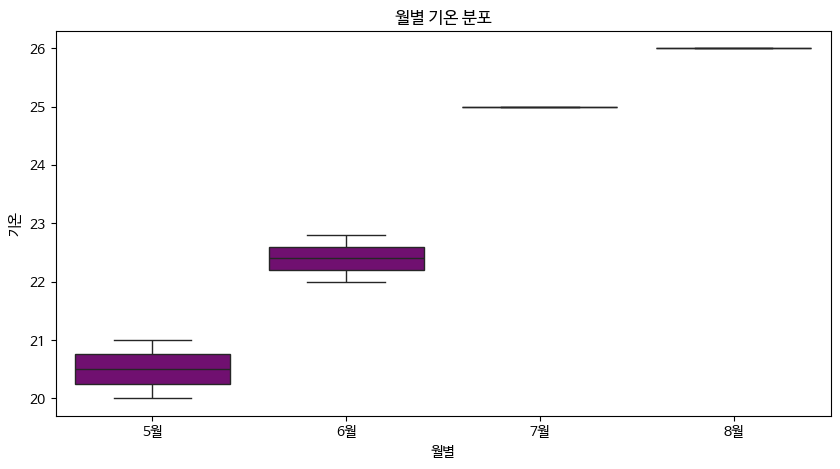

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import os
import warnings

# ---------------------------------------------------------
# 1. 환경 설정
# ---------------------------------------------------------
def setup_environment():
    warnings.filterwarnings('ignore')

    # 1. 시스템에 나눔 폰트가 있는지 확인 및 설치
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    if not os.path.exists(font_path):
        # Colab 등 리눅스 환경에서 폰트 설치
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    # 2. 폰트 매니저에 등록
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rc('font', family='NanumBarunGothic')
    else:
        # 윈도우 환경인 경우 'Malgun Gothic'
        plt.rc('font', family='Malgun Gothic' if os.name == 'nt' else 'AppleGothic')

    plt.rcParams['axes.unicode_minus'] = False
    print("✅ 환경 설정 및 한글 폰트 로드 완료")

setup_environment()

#--------------------------------------------------
# [단계 2] 샘플 데이터 생성 (협업 상황 시뮬레이션)
#--------------------------------------------------
#2021년 데이터 (풍속 누락), 2022년 데이터 (기온 일부 누락)
df_2021 = pd.DataFrame({'기온': [20,22,25]}, index =['5월','6월','7월'])
df_2022 = pd.DataFrame({'기온': [21,np.nan,26], '풍속': [3.2,4.1,3.8]} ,index =['5월','6월','8월'])
print("-"*100)
print(df_2021)
print(df_2022)

#--------------------------------------------------
# [단계 3] 모든 월과 컬럼을 유지하며 물리적으로 결합 axis = 0 , join = outer
#--------------------------------------------------
combined = pd.concat([df_2021,df_2022],axis=0,join='outer', keys=['2021년','2022년']) #keys로 년도 구별
print("-"*100)
print(combined)
print("\n",combined.index)
print("\n",combined.index.get_level_values(0)) #년도만 뽑기
print("\n",combined.index.get_level_values(1)) #월만 뽑기

#--------------------------------------------------
# [단계 4] df.fillna()를 활용한 전략적 결측치 처리
#--------------------------------------------------
clean_df= combined.fillna({ #fillna() 없는 값은 0으로 처리 시켜주는 함수
    '기온': combined['기온'].mean(), #기온은 평균값
    '풍속': 0.0   #풍속 데이터가 없으면 무풍(0) 처리
})
print("-"*100)
print("\n결측치 처리 후 \n", clean_df)

#--------------------------------------------------
# [단계 5] 시각화 (Seaborn.Boxplot으로 분포 확인) : 데이터프레임의 시각화는 seaborn 라이브러리 이용
#--------------------------------------------------
plt.figure(figsize=(10,5))
sns.boxplot(data=clean_df, x = clean_df.index.get_level_values(1),y='기온',color='purple')
plt.xlabel("월별")
plt.title("월별 기온 분포")
plt.show()














## ✅ Pandas
  - pd.merge()

In [ ]:
import pandas as pd

#----------------------------------------------------
#DataFrame 병합: 공유하는 특정 키 열을 기준으로 테이블을 결합 : merge()
#----------------------------------------------------
df_customers = pd.DataFrame({'ID': [1,2,3], 'Name': ['김','이','박']},index=['가','나','다']) #고객 정보
print(df_customers)

df_purchase_items=pd.DataFrame({'ID': [2,3,4,5],'Product':['스마트폰','노트북','태블릿','컴퓨터']}, index=['다','라','마','바']) #구매 정보
print("\n",df_purchase_items)

#----------------------------------------------------
# 1. ID 번호가 같은 사람끼리 정보 행을 합치기 : on = 'ID' , how = 'inner'
#----------------------------------------------------
# 행 번호는 자동으로 ID의 공통(교집합) 갯수만큼 생성, 컬럼명은 모두 나옴
inner_res =pd.merge(df_customers, df_purchase_items, on='ID', how='inner') #inner = 교집합 #on='기준' , how='집합'
print("\n",inner_res)

#----------------------------------------------------
# 2. ID를 기준으로 구매한 모든 정보 합치기: on='ID' , how='outer'
#----------------------------------------------------
# 행 번호는 자동으로 ID의 모든(합집합) 갯수만큼 생성, 컬럼명은 모두 나옴
outer_res=pd.merge(df_customers,df_purchase_items, on='ID', how='outer') #outer 합집합 #on='기준' , how='집합'
print("\n",outer_res)

#----------------------------------------------------
# 3. 왼쪽 테이블 '기준이 되는 마스터 명부 '에 정보를 덧붙이기. on='ID' , Left outer join (왼쪽 기준) -how='left'
#----------------------------------------------------
# 행 번호는 자동으로 왼쪽 테이블의 ID의 전체 갯수만큼 생성, 컬럼명은 모두 나옴
# 오른쪽 데이터프레임에는 없는 ID라면 해당 열은 NaN.
left_res=df_customers.merge(df_purchase_items, on='ID', how='left') #Name 기준?
print("\n",left_res)

#----------------------------------------------------
# 4. 오른쪾 테이블 '주문 기록을 기준으로 정보를 덧붙이기. on='ID' , Right outer join (왼쪽 기준) -how='right'
#----------------------------------------------------
# 행 번호는 자동으로 오른쪽 테이블의 ID의 전체 갯수만큼 생성, 컬럼명은 모두 나옴
# 왼쪽 데이터프레임에는 없는 ID라면 해당 열은 NaN.
right_res=df_customers.merge(df_purchase_items, on='ID', how='right') #Product 기준?
print("\n",right_res)

#GPT에게 물어볼 것 how에서 left와 right의 관계
#merge 무조건 시험에 나옴



   ID Name
가   1    김
나   2    이
다   3    박

    ID Product
다   2    스마트폰
라   3     노트북
마   4     태블릿
바   5     컴퓨터

    ID Name Product
0   2    이    스마트폰
1   3    박     노트북

    ID Name Product
0   1    김     NaN
1   2    이    스마트폰
2   3    박     노트북
3   4  NaN     태블릿
4   5  NaN     컴퓨터

    ID Name Product
0   1    김     NaN
1   2    이    스마트폰
2   3    박     노트북

    ID Name Product
0   2    이    스마트폰
1   3    박     노트북
2   4  NaN     태블릿
3   5  NaN     컴퓨터


## ✅ Pandas
  - pd.pivot_table()
  - pd.pivot()

In [ ]:
import pandas as pd

# 1. 데이터 생성
df_A = pd.DataFrame({'ID': [1,2,3], 'Name': ['김','이','박']}) #고객 정보
df_B=pd.DataFrame({'ID': [2,3,4,5],'Product':['스마트폰','노트북','태블릿','컴퓨터']}) #구매 정보

# 2. 데이터 병합: 'ID'를 기준으로 모든 고객과 구매 정보를 유지하도록 병합 (merge)
merged_df = df_A.merge(df_B, on='ID', how='outer')
print("\n 데이터 병합 후 테이블\n",merged_df)

# 3. 데이터 가공 (피벗 전 처리)
# (1) Name 열에서 Name이 없는 경우(신규 고객) '비회원'으로 채우고, 업데이트 하기
merged_df['Name'] = merged_df['Name'].fillna('비회원') #fillna 사용해서 NaN인 회원을 비회원으로 표시
print("\n 데이터 가공 후 테이블\n",merged_df)

# (2) 각 구매 수량을 1로 표시하는 '구매수량' 컬럼 추가하기
merged_df['구매수량'] = 1
print("-"*100)
print(merged_df)
print("-"*100)

# 4. 피벗 테이블 생성
# 행(index)은 고객 이름, 열(columns)은 상품명으로 설정하여 값(values)은 구매 수량을 집계.
pivot_table = merged_df.pivot_table(index='Name', columns='Product',values='구매수량',aggfunc='sum') #fill_value='0' 사용해도 NaN 0으로 채워짐 대신 1.0이 아니라 1
print("\n 피벗 테이블\n",pivot_table)
pivot_res=pivot_table.fillna(0) #이렇게 하면 1.0으로 유지 되면서 NaN이 0으로 바뀜
print("-"*100)
print("\n 피벗 테이블 \n",pivot_res)

















 데이터 병합 후 테이블
    ID Name Product
0   1    김     NaN
1   2    이    스마트폰
2   3    박     노트북
3   4  NaN     태블릿
4   5  NaN     컴퓨터

 데이터 가공 후 테이블
    ID Name Product
0   1    김     NaN
1   2    이    스마트폰
2   3    박     노트북
3   4  비회원     태블릿
4   5  비회원     컴퓨터
----------------------------------------------------------------------------------------------------
   ID Name Product  구매수량
0   1    김     NaN     1
1   2    이    스마트폰     1
2   3    박     노트북     1
3   4  비회원     태블릿     1
4   5  비회원     컴퓨터     1
----------------------------------------------------------------------------------------------------

 피벗 테이블
 Product  노트북  스마트폰  컴퓨터  태블릿
Name                        
박        1.0   NaN  NaN  NaN
비회원      NaN   NaN  1.0  1.0
이        NaN   1.0  NaN  NaN
----------------------------------------------------------------------------------------------------

 피벗 테이블 
 Product  노트북  스마트폰  컴퓨터  태블릿
Name                        
박        1.0   0.0  0.0  0.0
비회원      0.0   0.0  1.0  1.0
이    

## ✅ 시계열 날씨 데이터 (프로그래밍 과제)
- 웹상의 CSV 데이터를 읽어와 전처리(결측치 처리, 날짜 변환)를 수행하고,
- concat, merge, pivot_table 등 Pandas의 핵심 기능을 모두 포함한 통합 데이터 분석 파이프라인 코드를 작성.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import os
import warnings

# ---------------------------------------------------------
# 1. 환경 설정
# ---------------------------------------------------------
def setup_environment():
    warnings.filterwarnings('ignore')

    # 1. 시스템에 나눔 폰트가 있는지 확인 및 설치
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    if not os.path.exists(font_path):
        # Colab 등 리눅스 환경에서 폰트 설치
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    # 2. 폰트 매니저에 등록
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rc('font', family='NanumBarunGothic')
    else:
        # 윈도우 환경인 경우 'Malgun Gothic'
        plt.rc('font', family='Malgun Gothic' if os.name == 'nt' else 'AppleGothic')

    plt.rcParams['axes.unicode_minus'] = False
    print("✅ 환경 설정 및 한글 폰트 로드 완료")

setup_environment()

#-----------------------------------------------------------------
# 데이터 로드
#-----------------------------------------------------------------
path = 'https://github.com/dongupak/DataML/raw/main/csv/'
weather = pd.read_csv(path + 'weather.csv', index_col=0, encoding='CP949')
# weather = pd.read_csv(path + 'weather.csv', encoding='CP949')

# weather : DataFrame
print(weather.shape) #3654개의 샘플
print(weather.head())
print(type(weather)) #판다스 타입
print(weather.columns)
print(weather.index) #Index(['2010-08-01'...] -> DatetimeIndex 변환

✅ 환경 설정 및 한글 폰트 로드 완료
(3653, 3)
            평균기온  최대풍속  평균풍속
일시                          
2010-08-01  28.7   8.3   3.4
2010-08-02  25.2   8.7   3.8
2010-08-03  22.1   6.3   2.9
2010-08-04  25.3   6.6   4.2
2010-08-05  27.2   9.1   5.6
<class 'pandas.core.frame.DataFrame'>
Index(['평균기온', '최대풍속', '평균풍속'], dtype='object')
Index(['2010-08-01', '2010-08-02', '2010-08-03', '2010-08-04', '2010-08-05',
       '2010-08-06', '2010-08-07', '2010-08-08', '2010-08-09', '2010-08-10',
       ...
       '2020-07-22', '2020-07-23', '2020-07-24', '2020-07-25', '2020-07-26',
       '2020-07-27', '2020-07-28', '2020-07-29', '2020-07-30', '2020-07-31'],
      dtype='object', name='일시', length=3653)
